# Simulating stuff with synthpop and ocelot!

## Imports

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.gaia import Gaia
# import gaianir_open_clusters  # noqa: F401
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
from gaianir_open_clusters.population import simulate_region
from gaianir_open_clusters.gaia_nir_config import GAIANIR_ANGULAR_RESOLUTION
from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from ocelot.model.observation import (
    GaiaDR3ObservationModel,
    GenericSubsampleSelectionFunction,
)
from scipy.stats import poisson
from sklearn.neighbors import NearestNeighbors


## Region sim!

In [2]:
l = 180
b = 0

In [ ]:
region, area = simulate_region(l, b, 1/60**2, minimum_stars=10000)

Initializing populations for first time...
Simulating region... (attempt 1, area 1.000 arcsec^2)
  trying again; only have 139 stars
Simulating region... (attempt 2, area 143.885 arcsec^2)
  now adding photometry for 20916 stars...
Success! Calculating astrometry for 18762 remaining stars.


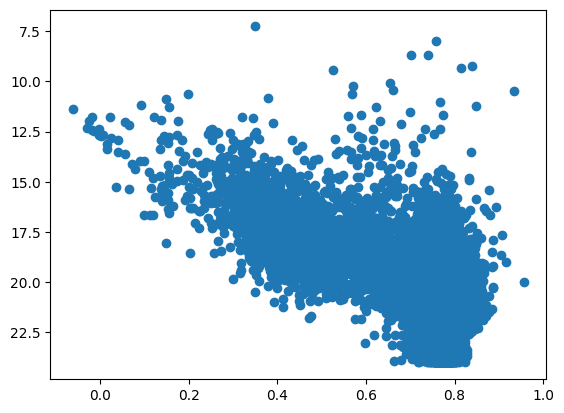

In [4]:
plt.scatter(region['N_J'] - region['N_K'], region['N'])
plt.gca().invert_yaxis()

## Cluster sim!

In [5]:
position = SkyCoord(
    l=l * u.deg,
    b=b * u.deg,
    distance=10000 * u.pc,
    pm_l_cosb=10 * u.mas / u.yr,
    pm_b=0 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="galactic",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=1000,
    log_age=9,
    metallicity=0.0,
    extinction=5.0,
    r_core=2,
    r_tidal=10,
    virial_ratio=0.5
)

In [6]:
Gaia.ROW_LIMIT = 10000
query = Gaia.cone_search(parameters.position, radius=0.5 * u.deg)
gaia_data = query.get_results().to_pandas().rename(columns={"SOURCE_ID": "source_id"})

In [9]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-M", years=10, maximum_magnitude=23
        ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=10,
        #     maximum_magnitude=20,
        #     combined_astrometry=False,
        # ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=5,
        #     maximum_magnitude=20,
        #     combined_astrometry=False,
        # ),
        GaiaDR3ObservationModel(
            representative_stars=gaia_data, overestimate_bp_rp_fluxes=False
        ),
    ]
)

In [10]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/ocelot/model/observation/gaia/gaia_dr3.py:226: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  magnitude = -2.5 * np.log10(flux, where=good_fluxes) + self.ZEROPOINTS[band]


In [11]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaianir-m-10-(combined)', 'gaia_dr3'])

## Various diagnostic plots

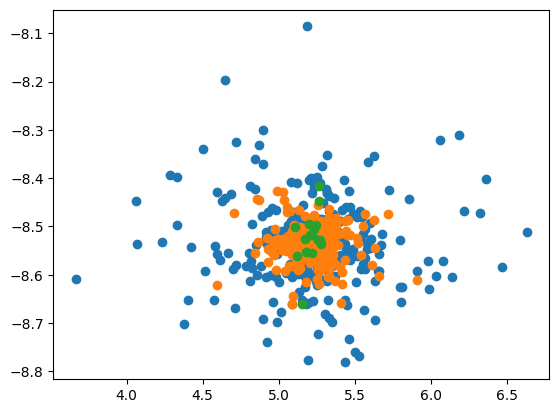

In [17]:
obs_m = cluster.observations['gaianir-m-10-(combined)'].query("gaianir_n < 22")
obs_l = cluster.observations['gaianir-l-10-(combined)'].query("gaianir_n < 22")
# obs_g = cluster.observations['gaia-10'].query("g_effective_gaia < 20")
obs_dr3 = cluster.observations['gaia_dr3'].query("gaia_dr3_g < 20")


plt.scatter(obs_m['pmra'], obs_m['pmdec'])
plt.scatter(obs_l['pmra'], obs_l['pmdec'])
# plt.scatter(obs_g['pmra'], obs_g['pmdec'])
plt.scatter(obs_dr3['pmra'], obs_dr3['pmdec'])

[None]

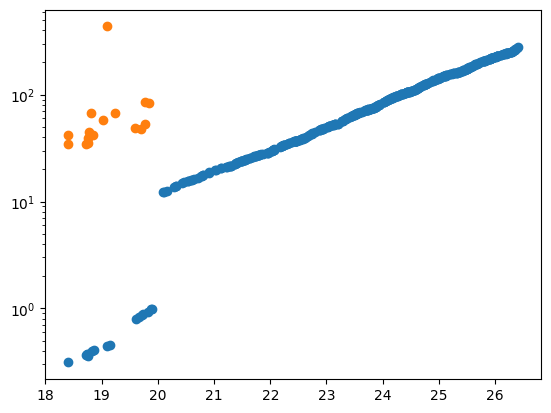

In [32]:
plt.scatter(obs_l['g_effective_gaia'], obs_l['pmra_error']*1000)
plt.scatter(obs_dr3['gaia_dr3_g'], obs_dr3['pmra_error']*1000)
plt.gca().set(yscale="log")

(array([13.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.03437771, 0.07439262, 0.11440754, 0.15442245, 0.19443737,
        0.23445229, 0.2744672 , 0.31448209, 0.35449702, 0.39451194,
        0.43452683]),
 <BarContainer object of 10 artists>)

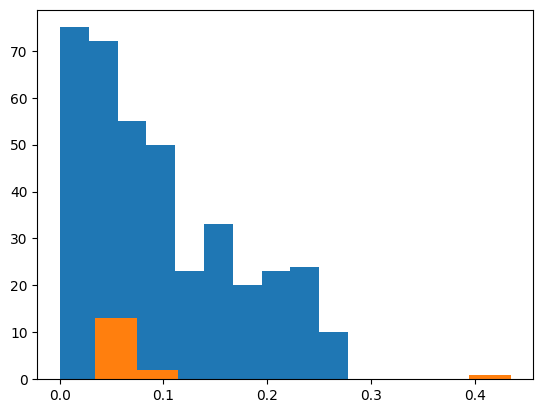

In [34]:
plt.hist(obs_l['pmra_error'])
plt.hist(obs_dr3['pmra_error'])
# plt.gca().set(yscale="log")

[Text(0.5, 0, 'G'), Text(0, 0.5, 'pmra error (uas/yr)')]

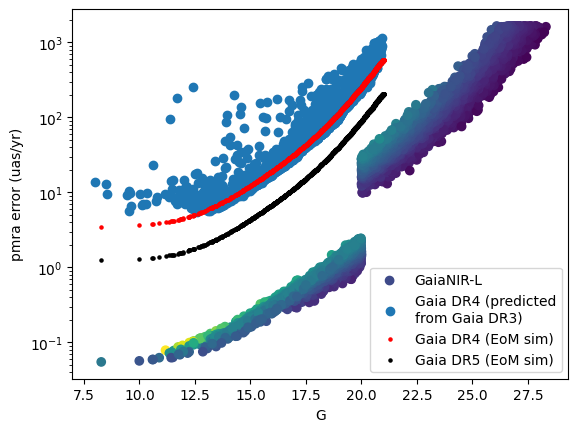

In [30]:
plt.scatter(
    region["Gaia_G_EDR3"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

plt.scatter(
    gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
)
plt.scatter(region["Gaia_G_EDR3"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["Gaia_G_EDR3"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="G", ylabel="pmra error (uas/yr)")

[Text(0.5, 0, 'N'), Text(0, 0.5, 'pmra error (uas/yr)')]

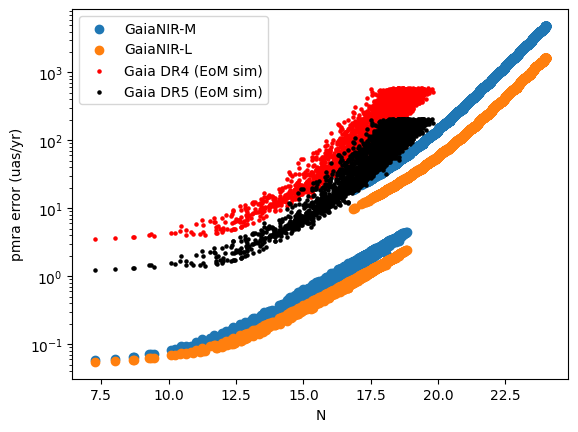

In [38]:
plt.scatter(
    region["N"],
    region["pmra_error_gaianir-m_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-M",
)
plt.scatter(
    region["N"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

# plt.scatter(
#     gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
# )
plt.scatter(region["N"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["N"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="N", ylabel="pmra error (uas/yr)")

## Dealing with crowding

Realization: it's just gonna be Poisson-distributed... hmm...

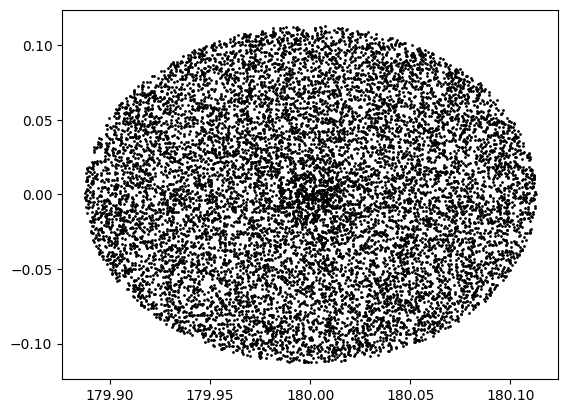

In [82]:
region_good = region.query("N < 22").reset_index(drop=True)
obs_good = (
    cluster.observations["gaianir-l-10-(combined)"]
    .query("gaianir_n < 22")
    .sort_values("gaianir_n", ascending=True)
    .reset_index(drop=True)
)

plt.scatter(region_good["l"], region_good["b"], s=1, c="k")
plt.scatter(obs_good["l"], obs_good["b"], s=1, c="k")
# plt.sca

HOW ABOUT: I use a fixed background event density, and then also have self-crowding for the cluster? This deals with within-cluster stochasticity AND also removes points nicely. Yay!

In [83]:
GAIANIR_ANGULAR_RESOLUTION

{'Gaia': 5.662482758620689e-07,
 'GaiaNIR-M': 1.1123529411764706e-06,
 'GaiaNIR-L': 5.402857142857143e-07}

FIRSTLY: self-crowding

In [110]:
values = np.radians(obs_good[['l', 'b']].to_numpy())
neighbor_estimator = NearestNeighbors(
    radius=GAIANIR_ANGULAR_RESOLUTION["GaiaNIR-L"], metric="haversine", n_jobs=1
).fit(values)

distances, indices = neighbor_estimator.radius_neighbors(values)

In [111]:
obs_good['selected'] = True

bad_stars = set()

for i_star, star in obs_good.iterrows():
    # No neighbors
    if len(indices[i_star]) == 1:
        continue

    # Already yeeted
    if i_star in bad_stars:
        continue

    # Has neighbors - since we have a sorted dataframe, we actually only need to do
    # other stars. The current star is always the brightest =)
    bad_stars.update(indices[i_star][1:])

In [112]:
len(bad_stars)

74

NEXT: crowding against the background

In [116]:
len(region_good), len(obs_good)

(11912, 385)

In [118]:
len(region_good) / (143.885/60**2)

298038.01647148764

In [ ]:
density = 

In [85]:
self_mag = obs_good['gaianir_n']

In [90]:
neighbor_mag = np.asarray([obs_good.loc[idx[1:], 'gaianir_n'].max() for idx in indices])

In [96]:
(neighbor_mag < self_mag).sum()

np.int64(35)